# The Death Cross — a quantitative teardown 🔬
### Real total-return tape · HAC inference · exposure-matched placebo · alpha-vs-beta

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Dodges crashes?: Confirmed](https://img.shields.io/badge/Dodges_crashes%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We separate the two things the death cross does — **reduce risk** (real) and **forecast return** (not certifiable) — and show the Sharpe gain is exposure, not skill.

> ⚠️ **Not investment advice.** SPY daily, total-return adjusted (`quantlab.data`, Yahoo); cash earns 0% (conservative); 5 bps/switch; one-day execution lag. Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (death_cross/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from death_cross import data, strategy

AS_OF = "2026-06-12"
frame = data.load_real("SPY", mode="total_return").loc[:AS_OF]
close = frame["close"]
pos = strategy.crossover_position(close, 50, 200, lag=1)
timer = strategy.backtest(close, pos, cost_bps=5.0)
bh = strategy.buy_and_hold(close)
print(f"SPY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(f"timer  Sharpe {timer['sharpe']:.3f}  maxDD {timer['max_dd']*100:.1f}%  CAGR {timer['cagr']*100:.2f}%  TiM {timer['time_in_market']*100:.0f}%")
print(f"B&H    Sharpe {bh['sharpe']:.3f}  maxDD {bh['max_dd']*100:.1f}%  CAGR {bh['cagr']*100:.2f}%")


SPY total return: 8,400 rows  1993-01-29 -> 2026-06-12  fingerprint=c43269c9d2be
timer  Sharpe 0.743  maxDD -33.7%  CAGR 9.64%  TiM 75%
B&H    Sharpe 0.646  maxDD -55.2%  CAGR 10.82%


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | `WEAK` | Sharpe edge over buy-and-hold **+0.097**, but HAC *t* on the daily return difference = **-0.99** (\|t\| < 2). It does beat a matched random coin 98% of the time, so the dates aren't pure noise. |
| **Tradability** | `MIRAGE` | Trails buy-and-hold by **1.2 pts/yr** (9.64% vs 10.82%); the Sharpe gain is lower beta, obtainable more cheaply. |
| **Dodges crashes?** | `CONFIRMED` | maxDD **-33.7%** vs **-55.2%**, vol **13.7%** vs **18.6%**. |

> 💡 **In plain words:** the death cross is a *risk reducer that works* wearing the costume of a *return booster that doesn't*.

## 1 · The claim, steelmanned

- **H₁ (risk):** the 50/200 filter lowers drawdown and volatility vs buy-and-hold.
- **H₂ (skill):** the crossover *dates* beat an exposure-matched random schedule.
- **H₃ (the sold claim):** the timer beats buy-and-hold on *return* / risk-adjusted return.

H₁ and H₂ can be true while H₃ is false — that is exactly the split we find.

## 2 · So what? — what rides on each answer

If H₃ held, cap-weighted indexing would be dominated by a two-line rule. It doesn't — and seeing *why* (beta, not alpha) is the lesson.

## 3 · How we'd know — the protocol

Decompose exposure vs timing · HAC inference on the return difference · exposure-matched placebo · alpha-vs-beta read on the Sharpe gap.

## 4 · The teardown

Headline stats, all net of 5 bps/switch:

In [2]:
tbl = pd.DataFrame({
  'CAGR %':   [timer['cagr']*100, bh['cagr']*100],
  'Vol %':    [timer['vol']*100, bh['vol']*100],
  'Sharpe':   [timer['sharpe'], bh['sharpe']],
  'MaxDD %':  [timer['max_dd']*100, bh['max_dd']*100],
  'TiM %':    [timer['time_in_market']*100, bh['time_in_market']*100],
}, index=['Death-cross timer', 'Buy & hold'])
tbl.round(2)

,CAGR %,Vol %,Sharpe,MaxDD %,TiM %
Death-cross timer,9.640,13.660,0.740,-33.720,75.110
Buy & hold,10.820,18.580,0.650,-55.190,100.000


**HAC inference** on the daily return difference (timer − buy-and-hold) — is the edge real?

In [3]:
diff = (timer['net'] - bh['net']).to_numpy()
t = strategy.hac_tstat(diff)
print(f'mean daily diff = {diff.mean()*1e4:+.3f} bps/day   HAC t = {t:+.2f}')
print('=> cannot reject zero: the return difference is not statistically distinguishable from 0.')

mean daily diff = -0.737 bps/day   HAC t = -0.99
=> cannot reject zero: the return difference is not statistically distinguishable from 0.


> 💡 **In plain words:** day to day, the timer and buy-and-hold are statistically the same bet; the timer just turns itself off during long declines.

**Exposure-matched placebo** — the same time in cash, random dates (200 seeds):

timer Sharpe 0.743 beats 195/200 coins (mean coin 0.564)
timer maxDD  -33.7% vs mean coin -51.0%


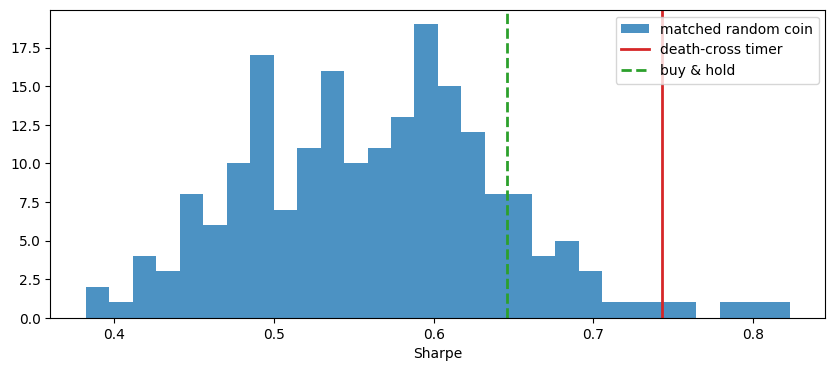

In [4]:
rand_s = np.array([strategy.backtest(close, strategy.matched_random_position(pos, seed=s), cost_bps=5.0)['sharpe'] for s in range(200)])
rand_dd = np.array([strategy.backtest(close, strategy.matched_random_position(pos, seed=s), cost_bps=5.0)['max_dd'] for s in range(200)])
print(f"timer Sharpe {timer['sharpe']:.3f} beats {(timer['sharpe']>rand_s).sum()}/200 coins (mean coin {rand_s.mean():.3f})")
print(f"timer maxDD  {timer['max_dd']*100:.1f}% vs mean coin {rand_dd.mean()*100:.1f}%")
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(rand_s, bins=30, alpha=.8, label='matched random coin')
ax.axvline(timer['sharpe'], color='C3', lw=2, label='death-cross timer')
ax.axvline(bh['sharpe'], color='C2', ls='--', lw=2, label='buy & hold')
ax.set_xlabel('Sharpe'); ax.legend(); plt.show()

> 💡 **In plain words:** the cross beats random in/out — so the *timing* adds something. But what it adds is risk reduction, and it still can't out-*earn* simply staying invested.

## 5 · The verdict

Signal `WEAK` (Sharpe +0.097, HAC *t* -0.99; beats coin 98%), Tradability `MIRAGE` (−1.2 pts/yr), Dodges crashes? `CONFIRMED` (-33.7% vs -55.2%). The Sharpe gain is exposure, not alpha.

## 6 · Could you trade it?

Capacity is a non-issue (SPY). The binding fact is economic, not frictional: the strategy delivers **less return for less risk** — a lower-beta portfolio — which a 75/25 stock/cash blend reproduces without 31 taxable switches. Net of tax the gap to buy-and-hold widens.

## 7 · Going further

- Replace 0% cash with the **T-bill** (`^IRX`) and recompute excess-of-cash for both arms.
- Bootstrap the Sharpe **difference** (stationary bootstrap) for a CI on +0.097.
- Cross-asset: does the filter earn its keep on assets with fatter left tails (EM, credit)?